In [1]:
# ==========================================
# Environment check (Kaggle TPU VM v5e-8)
# ==========================================
# Kaggle's TPU VM base image ships torch + torch_xla preinstalled and
# version-matched to the host libtpu. Reinstalling a different pinned
# wheel (as before) is what produced the encoder/TPU mismatch -- so we
# just verify versions instead of touching the install.
import os
import torch
import torch_xla


import torch.multiprocessing as mp
# avoids /dev/shm limits in constrained containers like Kaggle

print("torch      :", torch.__version__)
print("torch_xla  :", torch_xla.__version__)
print("torchvision:", end=" ")
import torchvision
print(torchvision.__version__)

/usr/local/lib/python3.12/site-packages/torch_xla/__init__.py:258: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


torch      : 2.8.0+cpu
torch_xla  : 2.8.0
torchvision: 0.23.0+cpu


In [2]:
# ==========================================
# Basic Imports
# ==========================================

import os
import gc
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image, ImageFilter

# ==========================================
# PyTorch
# ==========================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as T
from torchvision.models import resnet50, ResNet50_Weights

# ==========================================
# TPU Support
# ==========================================

import torch_xla.core.xla_model as xm
import torch_xla.distributed.parallel_loader as pl
import torch_xla.runtime as xr

# ==========================================
# Visualization
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Misc
# ==========================================

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [3]:
# ==========================================
# Reproducibility
# ==========================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ==========================================
# TPU Device
# ==========================================

# Improves matmul throughput on TPU (uses bf16 internally for fp32 matmuls)
torch.set_float32_matmul_precision("high")

DEVICE = xm.xla_device()

print("Device:", DEVICE)
print("Supported devices:", xm.get_xla_supported_devices())

# NOTE: a Kaggle TPU v5e-8 exposes 8 independent chips, but a plain
# xm.xla_device() call (same as used here) only claims a single chip.
# That is enough for this notebook and keeps the code simple/linear.
# To use all 8 chips, wrap the whole notebook body in a function and
# launch it with torch_xla.distributed.xla_multiprocessing.spawn(fn, nprocs=8),
# scaling batch_size and lr accordingly.

Device: xla:0
Supported devices: ['xla:0', 'xla:1', 'xla:2', 'xla:3', 'xla:4', 'xla:5', 'xla:6', 'xla:7']


E0000 00:00:1784376073.038014    4645 common_lib.cc:648] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: ===
learning/45eac/tfrc/runtime/common_lib.cc:238


In [4]:
# ==========================================
# Project Config
# ==========================================

CFG = {
    "img_size": 224,

    # Per-chip batch size. A single v5e chip has 16GB HBM, which comfortably
    # fits a ResNet50 SimCLR pass at 320x320 with room to spare -- bumped up
    # from 256 to better saturate the chip.
    "batch_size": 128,          # was 384

    "warmup_epochs": 5,         # new
    
    "num_workers": 8,          # was 8
    "prefetch_factor": 4,       # new

    "projection_dim": 256,
    "hidden_dim": 1024,
    "feature_dim": 2048,

    "temperature": 0.07,

    "epochs": 100,
    "lr": 3e-4,
    "weight_decay": 1e-4,

    # Kaggle TPU VM instances ship with a large CPU count, so the dataloader
    # can afford several workers to keep the TPU fed instead of stalling on
    # JPEG decode + augmentation.
    

    "pretrained_encoder": False,  # no internet on this dataset -> can't fetch ImageNet weights
}

CFG

{'img_size': 224,
 'batch_size': 128,
 'warmup_epochs': 5,
 'num_workers': 8,
 'prefetch_factor': 4,
 'projection_dim': 256,
 'hidden_dim': 1024,
 'feature_dim': 2048,
 'temperature': 0.07,
 'epochs': 100,
 'lr': 0.0003,
 'weight_decay': 0.0001,
 'pretrained_encoder': False}

In [5]:
# ==========================================
# Dataset Paths
# ==========================================

DATA_DIR = Path("/kaggle/input/datasets/ashery/chexpert")

print(DATA_DIR)

/kaggle/input/datasets/ashery/chexpert


In [6]:
# Quick inspection

for root, dirs, files in os.walk(DATA_DIR):
    print(root)

    if len(files) > 0:
        print("Example file:", files[0])

    break

/kaggle/input/datasets/ashery/chexpert
Example file: valid.csv


In [7]:
# Load metadata

train_df = pd.read_csv(DATA_DIR / "train.csv")
valid_df = pd.read_csv(DATA_DIR / "valid.csv")

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)

Train shape: (223414, 19)
Valid shape: (234, 19)


In [8]:
# Columns, first rows, and label value ranges

print(train_df.columns.tolist())
display(train_df.head())

for col in train_df.columns[5:]:
    print(col, train_df[col].dropna().unique())

['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


No Finding [1.]
Enlarged Cardiomediastinum [ 0.  1. -1.]
Cardiomegaly [-1.  0.  1.]
Lung Opacity [ 1.  0. -1.]
Lung Lesion [ 1. -1.  0.]
Edema [-1.  1.  0.]
Consolidation [-1.  0.  1.]
Pneumonia [ 0. -1.  1.]
Atelectasis [-1.  1.  0.]
Pneumothorax [ 0.  1. -1.]
Pleural Effusion [-1.  0.  1.]
Pleural Other [ 1. -1.  0.]
Fracture [ 1.  0. -1.]
Support Devices [ 1.  0. -1.]


In [9]:
# Disease labels

LABEL_COLS = [
    'No Finding',
    'Enlarged Cardiomediastinum',
    'Cardiomegaly',
    'Lung Opacity',
    'Lung Lesion',
    'Edema',
    'Consolidation',
    'Pneumonia',
    'Atelectasis',
    'Pneumothorax',
    'Pleural Effusion',
    'Pleural Other',
    'Fracture',
    'Support Devices'
]

LABEL_COLS

['No Finding',
 'Enlarged Cardiomediastinum',
 'Cardiomegaly',
 'Lung Opacity',
 'Lung Lesion',
 'Edema',
 'Consolidation',
 'Pneumonia',
 'Atelectasis',
 'Pneumothorax',
 'Pleural Effusion',
 'Pleural Other',
 'Fracture',
 'Support Devices']

In [10]:
# Label counts and missing values

for col in LABEL_COLS:
    positives = (train_df[col] == 1).sum()
    print(f"{col}: {positives}")

print()
print("Missing values per label:")
print(train_df[LABEL_COLS].isna().sum())

No Finding: 22381
Enlarged Cardiomediastinum: 10798
Cardiomegaly: 27000
Lung Opacity: 105581
Lung Lesion: 9186
Edema: 52246
Consolidation: 14783
Pneumonia: 6039
Atelectasis: 33376
Pneumothorax: 19448
Pleural Effusion: 86187
Pleural Other: 3523
Fracture: 9040
Support Devices: 116001

Missing values per label:
No Finding                    201033
Enlarged Cardiomediastinum    178575
Cardiomegaly                  177211
Lung Opacity                  105636
Lung Lesion                   211470
Edema                         137458
Consolidation                 152792
Pneumonia                     195806
Atelectasis                   154971
Pneumothorax                  144480
Pleural Effusion               90203
Pleural Other                 216922
Fracture                      211220
Support Devices               100197
dtype: int64


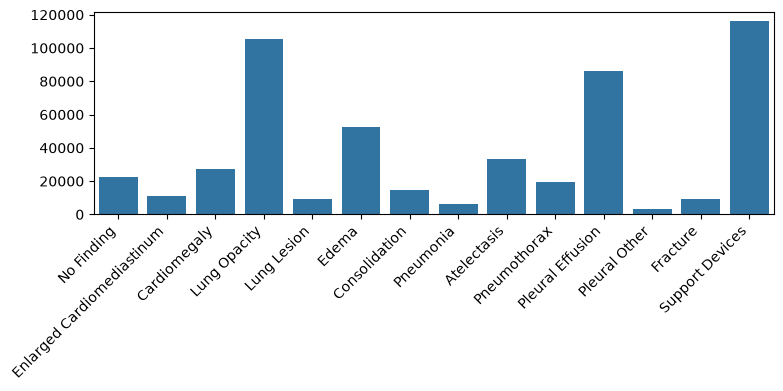

In [11]:
# Positive label distribution

counts = [(train_df[col] == 1).sum() for col in LABEL_COLS]

plt.figure(figsize=(8, 4))
sns.barplot(x=LABEL_COLS, y=counts)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/kaggle/input/datasets/ashery/chexpert/train/patient00001/study1/view1_frontal.jpg | exists: True
<class 'PIL.JpegImagePlugin.JpegImageFile'> (389, 320)


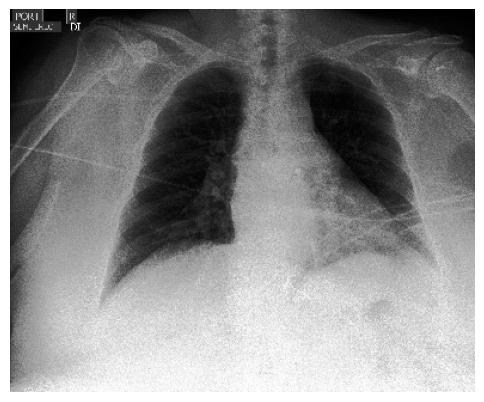

In [12]:
# Example image: resolve path, load, and visualize

sample_path = train_df.iloc[0]["Path"]
fixed_path = sample_path.replace("CheXpert-v1.0-small/", "")

img_path = DATA_DIR / fixed_path
print(img_path, "| exists:", img_path.exists())

img = Image.open(img_path)
print(type(img), img.size)

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

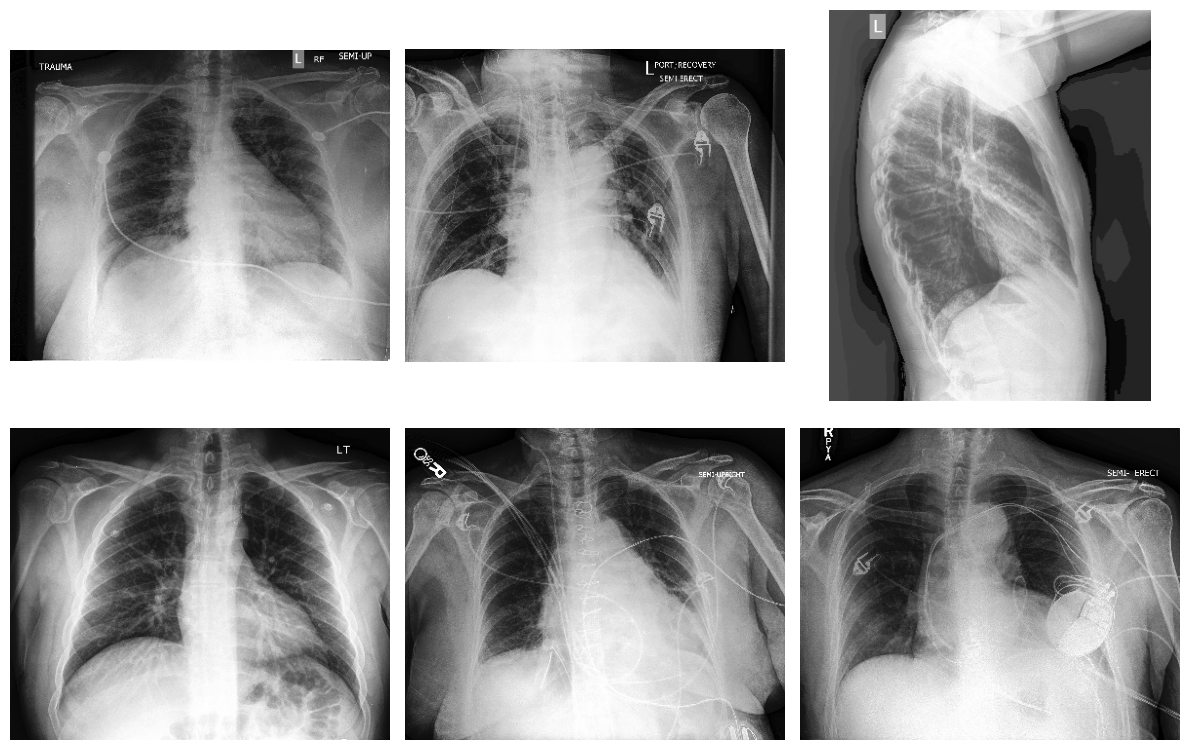

In [13]:
# Random sample grid

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax in axes.flatten():
    idx = np.random.randint(len(train_df))
    sample_path = train_df.iloc[idx]["Path"].replace("CheXpert-v1.0-small/", "")
    img = Image.open(DATA_DIR / sample_path)

    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
# Sample image dimensions

sizes = []

for idx in np.random.choice(len(train_df), 500, replace=False):
    path = train_df.iloc[idx]["Path"].replace("CheXpert-v1.0-small/", "")
    img = Image.open(DATA_DIR / path)
    sizes.append(img.size)

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print("Width:")
print(pd.Series(widths).describe())
print()
print("Height:")
print(pd.Series(heights).describe())

Width:
count    500.000000
mean     372.626000
std       29.279082
min      320.000000
25%      360.750000
50%      390.000000
75%      390.000000
max      419.000000
dtype: float64

Height:
count    500.000000
mean     324.680000
std       16.101556
min      320.000000
25%      320.000000
50%      320.000000
75%      320.000000
max      432.000000
dtype: float64


In [15]:
# Demographic / view breakdown

print(train_df["Frontal/Lateral"].value_counts())
print()
print(train_df["AP/PA"].value_counts(dropna=False))
print()
print(train_df["Sex"].value_counts(dropna=False))
print()
print(train_df["Age"].describe())

Frontal/Lateral
Frontal    191027
Lateral     32387
Name: count, dtype: int64

AP/PA
AP     161590
NaN     32387
PA      29420
LL         16
RL          1
Name: count, dtype: int64

Sex
Male       132636
Female      90777
Unknown         1
Name: count, dtype: int64

count    223414.000000
mean         60.430653
std          17.820925
min           0.000000
25%          49.000000
50%          62.000000
75%          74.000000
max          90.000000
Name: Age, dtype: float64


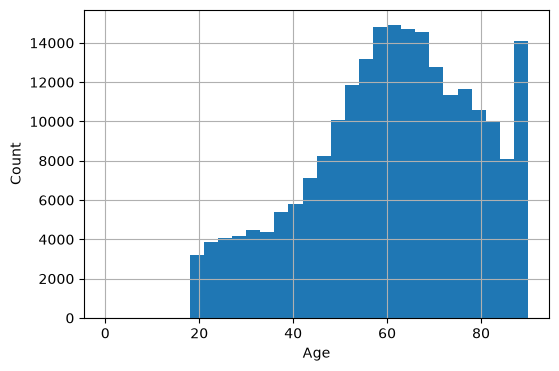

In [16]:
plt.figure(figsize=(6, 4))
train_df["Age"].hist(bins=30)
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [17]:
# Keep frontal images only (lateral views are a small, noisier minority)

train_df = train_df[train_df["Frontal/Lateral"] == "Frontal"].reset_index(drop=True)
valid_df = valid_df[valid_df["Frontal/Lateral"] == "Frontal"].reset_index(drop=True)

print(train_df.shape)
print(valid_df.shape)

(191027, 19)
(202, 19)


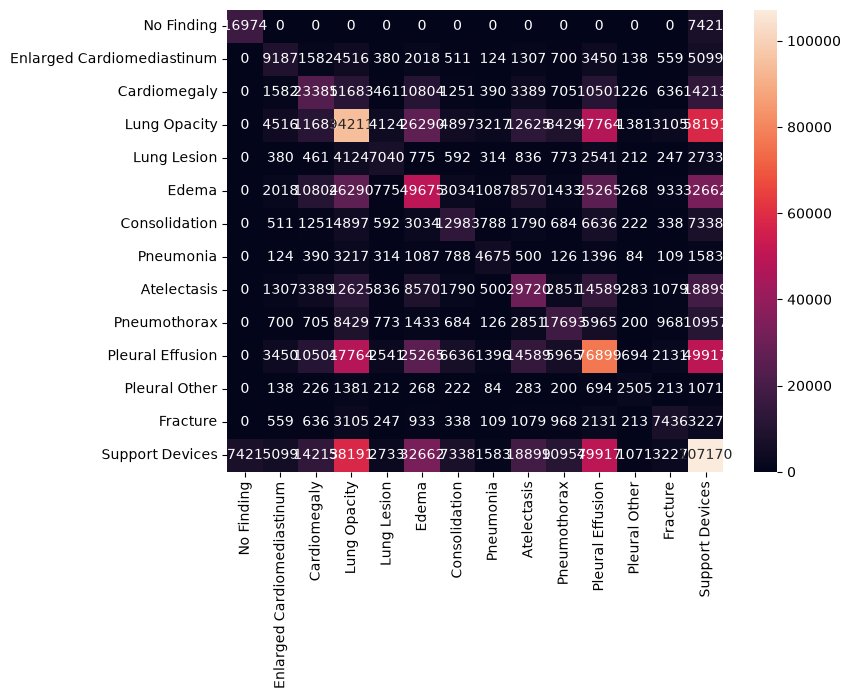

In [18]:
# Label co-occurrence

label_df = train_df[LABEL_COLS].fillna(0).replace(-1, 0)
co_occurrence = label_df.T @ label_df

plt.figure(figsize=(8, 6))
sns.heatmap(co_occurrence, annot=True, fmt=".0f")
plt.show()

In [19]:
# Coarse concept grouping -- not used by the SimCLR phase below, kept as a
# starting point if a supervised-contrastive (SupCon) phase is added later,
# mirroring the two-phase (SSL -> SupCon) structure used in the ECG notebook.

CONCEPT_MAP = {
    "No Finding": 0,
    "Cardiomegaly": 1,
    "Edema": 2,
    "Pleural Effusion": 2,
    "Support Devices": 3
}

In [20]:
# Clean CheXpert labels (missing -> 0, uncertain (-1) -> 0)

def clean_labels(df, label_cols):
    labels = df[label_cols].copy()
    labels = labels.fillna(0)
    labels = labels.replace(-1, 0)
    return labels.astype(np.float32)

clean_train_labels = clean_labels(train_df, LABEL_COLS)
clean_valid_labels = clean_labels(valid_df, LABEL_COLS)

clean_train_labels.head()

,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
# ==========================================
# Augmentations
# ==========================================

class GaussianBlur:
    """Random Gaussian blur, following the SimCLR augmentation recipe."""

    def __init__(self, radius_min=0.1, radius_max=2.0):
        self.radius_min = radius_min
        self.radius_max = radius_max

    def __call__(self, img):
        radius = np.random.uniform(self.radius_min, self.radius_max)
        return img.filter(ImageFilter.GaussianBlur(radius))

In [22]:
simclr_transform = T.Compose([
    # was scale=(0.80, 1.0) -- far too weak, made the two views nearly
    # identical and let the pretext task collapse in ~3 epochs
    T.RandomResizedCrop(size=CFG["img_size"], scale=(0.3, 1.0)),

    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),

    # widened slightly to match the wider crop range
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),

    # new: intensity/contrast jitter -- grayscale-safe (no hue/saturation),
    # forces the encoder to be invariant to exposure/windowing differences
    # instead of just crop position
    T.RandomApply([T.ColorJitter(brightness=0.4, contrast=0.4)], p=0.8),

    T.RandomApply([GaussianBlur()], p=0.5),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [23]:
# Wraps a single transform to produce two augmented views per image (SimCLR)

class SimCLRTransform:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, image):
        view1 = self.transform(image)
        view2 = self.transform(image)
        return view1, view2

train_transform = SimCLRTransform(simclr_transform)

In [24]:
# Sanity check on the augmentation pipeline

sample_path = DATA_DIR / train_df.iloc[0]["Path"].replace("CheXpert-v1.0-small/", "")
image = Image.open(sample_path).convert("L")

view1, view2 = train_transform(image)
print(view1.shape, view2.shape)

torch.Size([3, 224, 224]) torch.Size([3, 224, 224])


In [25]:
from PIL import Image, ImageFilter, UnidentifiedImageError

class CheXpertDataset(Dataset):

    def __init__(self, dataframe, data_dir, transform=None, label_cols=None, return_labels=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.return_labels = return_labels
        self.label_cols = label_cols

        if self.return_labels and self.label_cols is not None:
            labels = self.dataframe[self.label_cols].fillna(0).replace(-1, 0)
            self.labels = labels.astype(np.float32).values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.data_dir / self.dataframe.iloc[idx]["Path"].replace("CheXpert-v1.0-small/", "")

        try:
            image = Image.open(image_path).convert("L")
        except (OSError, UnidentifiedImageError):
            return self.__getitem__(np.random.randint(len(self.dataframe)))

        if self.transform is not None:
            image = self.transform(image)

        if not self.return_labels:
            return image

        labels = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, labels

In [26]:
# SimCLR training dataset

train_dataset = CheXpertDataset(
    dataframe=train_df,
    data_dir=DATA_DIR,
    transform=train_transform,
    return_labels=False
)

print("Dataset size:", len(train_dataset))

view1, view2 = train_dataset[0]
print(view1.shape, view2.shape)

Dataset size: 191027
torch.Size([3, 224, 224]) torch.Size([3, 224, 224])


In [27]:
train_DataLoader = DataLoader(
    train_dataset,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    persistent_workers=True,
    prefetch_factor=CFG["prefetch_factor"],
    drop_last=True
)

In [28]:

# Wrap with MpDeviceLoader so batches are prefetched onto the TPU device
# asynchronously, overlapping host-side augmentation with device compute.
train_loader = pl.MpDeviceLoader(train_DataLoader, DEVICE)

# Sanity check on TPU
view1, view2 = next(iter(train_loader))
sz = CFG["img_size"]
print(f"View batch : {view1.shape}   -> (batch, 3, {sz}, {sz})")
print("Device     :", view1.device)

View batch : torch.Size([128, 3, 224, 224])   -> (batch, 3, 224, 224)
Device     : xla:0


In [29]:
# ==========================================
# ResNet50 Encoder
# ==========================================

class ResNet50Encoder(nn.Module):

    def __init__(self, pretrained=False):
        super().__init__()

        # No internet access on this dataset -> ImageNet weights can't be
        # downloaded, so pretrained defaults to False (see CFG["pretrained_encoder"]).
        weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None

        backbone = resnet50(weights=weights)
        backbone.fc = nn.Identity()  # remove classification head

        self.backbone = backbone
        self.feature_dim = 2048

    def forward(self, x):
        return self.backbone(x)

In [30]:
# Initialize + test encoder

encoder = ResNet50Encoder(pretrained=CFG["pretrained_encoder"]).to(DEVICE)

view1, view2 = next(iter(train_loader))
with torch.no_grad():
    features = encoder(view1)

print("Features:", features.shape)

Features: torch.Size([128, 2048])


In [31]:
# ==========================================
# Projection Head + SimCLR wrapper
# ==========================================

class ProjectionHead(nn.Module):

    def __init__(self):
        super().__init__()

        self.projector = nn.Sequential(
            nn.Linear(CFG["feature_dim"], CFG["hidden_dim"]),
            nn.BatchNorm1d(CFG["hidden_dim"]),
            nn.ReLU(inplace=True),
            nn.Linear(CFG["hidden_dim"], CFG["projection_dim"])
        )

    def forward(self, x):
        return self.projector(x)


class SimCLR(nn.Module):

    def __init__(self, pretrained=False):
        super().__init__()
        self.encoder = ResNet50Encoder(pretrained=pretrained)
        self.projector = ProjectionHead()

    def forward(self, x):
        features = self.encoder(x)
        embeddings = self.projector(features)
        return features, embeddings

In [32]:
# Initialize + test model

model = SimCLR(pretrained=CFG["pretrained_encoder"]).to(DEVICE)

view1, view2 = next(iter(train_loader))


with torch.no_grad():
    features, embeddings = model(view1)

print("Features  :", features.shape)
print("Embeddings:", embeddings.shape)

Features  : torch.Size([128, 2048])
Embeddings: torch.Size([128, 256])


In [33]:
# ==========================================
# NT-Xent Loss
# ==========================================
class NTXentLoss(nn.Module):

    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature
        self._cached_batch_size = None
        self._mask = None
        self._labels = None

    def _build_cache(self, batch_size, device):
        self._mask = torch.eye(2 * batch_size, dtype=torch.bool, device=device)
        self._labels = torch.cat([
            torch.arange(batch_size, 2 * batch_size),
            torch.arange(batch_size)
        ]).to(device)
        self._cached_batch_size = batch_size

    def forward(self, z1, z2):
        # explicit fp32 cast -- don't rely on XLA autocast's op-allowlist for this
        z1 = F.normalize(z1.float(), dim=1)
        z2 = F.normalize(z2.float(), dim=1)

        batch_size = z1.size(0)
        z = torch.cat([z1, z2], dim=0)

        similarity = torch.matmul(z, z.T) / self.temperature

        if self._cached_batch_size != batch_size:
            self._build_cache(batch_size, similarity.device)

        similarity = similarity.masked_fill(self._mask, torch.finfo(similarity.dtype).min)

        return F.cross_entropy(similarity, self._labels)

criterion = NTXentLoss(temperature=CFG["temperature"])

# Sanity check
view1, view2 = next(iter(train_loader))
with torch.no_grad():
    _, z1 = model(view1)
    _, z2 = model(view2)

print("Sanity loss:", criterion(z1, z2).item())

Sanity loss: 7.778011322021484


In [34]:
# ==========================================
# Optimizer + Scheduler
# ==========================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"]
)
# OLD:
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["epochs"])

# NEW:
warmup = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    total_iters=CFG["warmup_epochs"]
)

cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG["epochs"] - CFG["warmup_epochs"]
)

scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup, cosine],
    milestones=[CFG["warmup_epochs"]]
)

print(optimizer)
print(scheduler)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.0003
    lr: 2.9999999999999997e-05
    maximize: False
    weight_decay: 0.0001
)


In [35]:
def train_one_epoch(model, loader, optimizer, criterion, log_every=50):
    model.train()
    running_loss = torch.zeros((), device=DEVICE)
    num_batches = 0

    progress_bar = tqdm(loader)

    for view1, view2 in progress_bar:
        # concatenate both views into one batch -> single forward pass
        images = torch.cat([view1, view2], dim=0)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="xla", dtype=torch.bfloat16):
            _, z = model(images)
            z1, z2 = z.chunk(2, dim=0)
            loss = criterion(z1, z2)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        xm.optimizer_step(optimizer, barrier=True)
        # (no separate xm.mark_step() -- barrier=True already does that)

        running_loss += loss.detach()
        num_batches += 1

        if num_batches % log_every == 0:
            progress_bar.set_postfix(loss=f"{(running_loss / num_batches).item():.4f}")

    return (running_loss / num_batches).item()

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

# deterministic preprocessing for probe eval -- no augmentation
eval_transform = T.Compose([
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# subsample train_df for probe fitting -- don't need the full 190k images
# to fit a linear head, and this keeps the eval fast enough to run every
# few epochs
probe_train_df = train_df.sample(n=min(3000, len(train_df)), random_state=SEED).reset_index(drop=True)

probe_train_dataset = CheXpertDataset(
    probe_train_df, DATA_DIR, transform=eval_transform,
    label_cols=LABEL_COLS, return_labels=True
)
probe_valid_dataset = CheXpertDataset(
    valid_df, DATA_DIR, transform=eval_transform,
    label_cols=LABEL_COLS, return_labels=True
)

probe_train_loader = pl.MpDeviceLoader(
    DataLoader(probe_train_dataset, batch_size=256, shuffle=False, num_workers=4),
    DEVICE
)
probe_valid_loader = pl.MpDeviceLoader(
    DataLoader(probe_valid_dataset, batch_size=256, shuffle=False, num_workers=4),
    DEVICE
)

@torch.no_grad()
def extract_features(encoder, loader):
    encoder.eval()
    feats, labels = [], []
    for images, targets in loader:
        f = encoder(images)
        feats.append(f.detach().cpu())
        labels.append(targets.detach().cpu())
    return torch.cat(feats).numpy(), torch.cat(labels).numpy()

def linear_probe_auroc(encoder):
    """Freeze encoder, fit a linear head per label on frozen features,
    return mean AUROC on the held-out valid_df labels. This is the actual
    signal of representation quality -- NT-Xent loss alone can't tell you
    this, as we just saw."""
    X_train, y_train = extract_features(encoder, probe_train_loader)
    X_valid, y_valid = extract_features(encoder, probe_valid_loader)

    aurocs = []
    for i, col in enumerate(LABEL_COLS):
        y_tr, y_va = y_train[:, i], y_valid[:, i]

        # skip labels with only one class present -- AUROC undefined
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_va)) < 2:
            continue

        clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
        clf.fit(X_train, y_tr)
        preds = clf.predict_proba(X_valid)[:, 1]
        aurocs.append(roc_auc_score(y_va, preds))

    return float(np.mean(aurocs)) if aurocs else float("nan")

In [37]:
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

CHECKPOINT_EVERY = 5   # save a resumable checkpoint every N epochs
EVAL_EVERY = 10         # run the linear probe every N epochs
PATIENCE = 3            # stop if probe AUROC doesn't improve for this many evals

history = []
probe_history = []
best_auroc = -1.0
patience_counter = 0

In [ ]:


for epoch in range(START_EPOCH,CFG["epochs"]):
    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
    )

    scheduler.step()
    history.append(train_loss)

    xm.master_print(
        f"Epoch [{epoch + 1}/{CFG['epochs']}] "
        f"Loss: {train_loss:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.2e}"
    )

    # ---- resumable checkpoint ----
    if (epoch + 1) % CHECKPOINT_EVERY == 0 or (epoch + 1) == CFG["epochs"]:
        xm.save({
            "epoch": epoch + 1,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "history": history,
        }, CHECKPOINT_DIR / "latest.pth")
        xm.master_print(f"  -> checkpoint saved at epoch {epoch + 1}")

    # ---- linear-probe validation + early stopping on real signal ----
    if (epoch + 1) % EVAL_EVERY == 0 or (epoch + 1) == CFG["epochs"]:
        auroc = linear_probe_auroc(model.encoder)
        probe_history.append((epoch + 1, auroc))
        xm.master_print(f"  -> linear probe mean AUROC: {auroc:.4f}")

        if auroc > best_auroc:
            best_auroc = auroc
            patience_counter = 0
            xm.save(model.encoder.state_dict(), CHECKPOINT_DIR / "encoder_best.pth")
            xm.master_print(f"  -> new best encoder saved (AUROC={auroc:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                xm.master_print(
                    f"No AUROC improvement for {PATIENCE} evals -- stopping early at epoch {epoch + 1}"
                )
                break

In [ ]:
START_EPOCH = 0
history = []
probe_history = []
best_auroc = -1.0
patience_counter = 0

resume_path = CHECKPOINT_DIR / "latest.pth"
if resume_path.exists():
    ckpt = torch.load(resume_path, map_location="cpu")

    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])

    # optimizer state (Adam moments) loads as CPU tensors -- move them onto
    # the XLA device or you'll get a device-mismatch error on the next step
    for state in optimizer.state.values():
        for k, v in state.items():
            if torch.is_tensor(v):
                state[k] = v.to(DEVICE)

    scheduler.load_state_dict(ckpt["scheduler_state"])
    history = ckpt["history"]
    START_EPOCH = ckpt["epoch"]

    xm.master_print(f"Resumed from checkpoint at epoch {START_EPOCH}")
else:
    xm.master_print("No checkpoint found -- starting fresh")

In [ ]:
START_EPOCH

In [38]:
def linear_probe_auroc(encoder, verbose=True):
    X_train, y_train = extract_features(encoder, probe_train_loader)
    X_valid, y_valid = extract_features(encoder, probe_valid_loader)

    per_label = {}
    for i, col in enumerate(LABEL_COLS):
        y_tr, y_va = y_train[:, i], y_valid[:, i]
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_va)) < 2:
            continue
        clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
        clf.fit(X_train, y_tr)
        preds = clf.predict_proba(X_valid)[:, 1]
        per_label[col] = roc_auc_score(y_va, preds)

    if verbose:
        for col, score in per_label.items():
            xm.master_print(f"      {col}: {score:.4f}")
        skipped = [c for c in LABEL_COLS if c not in per_label]
        if skipped:
            xm.master_print(f"      (skipped, insufficient class variance: {skipped})")

    return float(np.mean(list(per_label.values()))) if per_label else float("nan")

In [ ]:
# ==========================================
# Save encoder checkpoint
# ==========================================

xm.save(model.encoder.state_dict(), "image_encoder_simclr.pth")

In [ ]:
# ==========================================
# Load frozen SimCLR encoder -- the BEST checkpoint, not the last epoch
# ==========================================

encoder = ResNet50Encoder(pretrained=False)
encoder.load_state_dict(torch.load(CHECKPOINT_DIR / "encoder_best.pth"))
encoder = encoder.to(DEVICE)

for p in encoder.parameters():
    p.requires_grad = False

In [ ]:
# ==========================================
# Classifier head on top of the frozen encoder
# ==========================================

class CheXpertClassifier(nn.Module):
    def __init__(self, encoder, n_classes=len(LABEL_COLS), dropout=0.3):
        super().__init__()

        self.encoder = encoder  # frozen

        self.head = nn.Sequential(
            nn.Linear(encoder.feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        with torch.no_grad():  # freeze encoder
            feats = self.encoder(x)

        return self.head(feats)


model = CheXpertClassifier(encoder).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

In [ ]:
# ==========================================
# Deterministic eval-style transform (no SimCLR augmentation)
# ==========================================

eval_transform = T.Compose([
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:

 # ==========================================
# Labeled datasets + TPU dataloaders
# ==========================================

clf_train_dataset = CheXpertDataset(
    
    dataframe=train_df,
    data_dir=DATA_DIR,
    transform=eval_transform,
    label_cols=LABEL_COLS,
    return_labels=True
)

clf_valid_dataset = CheXpertDataset(
    dataframe=valid_df,
    data_dir=DATA_DIR,
    transform=eval_transform,
    label_cols=LABEL_COLS,
    return_labels=True
)

clf_train_DataLoader = DataLoader(
    clf_train_dataset,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    prefetch_factor=CFG["prefetch_factor"],
    persistent_workers=True,
    drop_last=True
)

clf_valid_DataLoader = DataLoader(
    clf_valid_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    prefetch_factor=CFG["prefetch_factor"],
    persistent_workers=True,
    drop_last=False
)

# ✅ Wrap with MpDeviceLoader for TPU
clf_train_loader = pl.MpDeviceLoader(clf_train_DataLoader, DEVICE)
clf_valid_loader = pl.MpDeviceLoader(clf_valid_DataLoader, DEVICE)

# Sanity check on TPU
img, lab = next(iter(clf_train_loader))
print(f'Image batch : {img.shape}')
print(f'Label batch : {lab.shape}   -> (batch, {len(LABEL_COLS)} classes)')

In [ ]:
# ==========================================
# Class imbalance -> pos_weight for BCE
# ==========================================

pos_counts = clean_train_labels.sum(axis=0).values
neg_counts = len(clean_train_labels) - pos_counts

POS_WEIGHT = torch.tensor(neg_counts / np.clip(pos_counts, 1, None), dtype=torch.float32)
print(POS_WEIGHT)

In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT.to(DEVICE))
optimizer = torch.optim.Adam(model.head.parameters(), lr=1e-3)  # only the trainable head

EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    running_loss = torch.zeros((), device=DEVICE)
    num_batches = 0

    progress_bar = tqdm(clf_train_loader)

    for images, labels in progress_bar:
        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        xm.optimizer_step(optimizer, barrier=True)

        running_loss += loss.detach()
        num_batches += 1

        if num_batches % 50 == 0:
            progress_bar.set_postfix(loss=f"{(running_loss / num_batches).item():.4f}")

    xm.master_print(f"Epoch {epoch}: Train Loss = {(running_loss / num_batches).item():.4f}")

In [ ]:
# ==========================================
# Validation loss
# ==========================================

model.eval()
val_loss = 0

with torch.no_grad():
    for images, labels in clf_valid_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        val_loss += loss.item()

val_loss /= len(clf_valid_loader)
print(f"Val Loss = {val_loss:.4f}")

In [ ]:
# ==========================================
# Macro AUC evaluation
# ==========================================

from sklearn.metrics import roc_auc_score

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in clf_valid_loader:
        outputs = model(images)
        probs = torch.sigmoid(outputs)

        y_pred.append(probs.cpu().numpy())
        y_true.append(labels.cpu().numpy())

y_pred = np.vstack(y_pred)
y_true = np.vstack(y_true)

per_label_auc = {}
for i, col in enumerate(LABEL_COLS):
    y_va = y_true[:, i]
    if len(np.unique(y_va)) < 2:
        continue  # only one class present in this 202-image split -- AUC undefined
    per_label_auc[col] = roc_auc_score(y_va, y_pred[:, i])

for col, score in per_label_auc.items():
    print(f"  {col}: {score:.4f}")

skipped = [c for c in LABEL_COLS if c not in per_label_auc]
if skipped:
    print(f"  (skipped, only one class present in valid split: {skipped})")

macro_auc = float(np.mean(list(per_label_auc.values()))) if per_label_auc else float("nan")
print("Validation AUC (macro, over scoreable labels):", macro_auc)

In [39]:
SHARED_LABELS = [
    "No Finding",
    "Cardiomegaly",
    "Enlarged Cardiomediastinum",
    "Edema",
    "Pleural Effusion",
]

In [40]:
# ==========================================
# Multi-label SupCon loss (image version)
# ==========================================

def label_similarity(y):
    """
    y: (2B, C) multi-hot labels
    returns: (2B, 2B) Jaccard-style label similarity
    """
    y = y.float()
    intersection = torch.matmul(y, y.T)

    y_sum = y.sum(dim=1, keepdim=True)
    union = y_sum + y_sum.T - intersection + 1e-8

    sim = intersection / union
    return sim


def multilabel_supcon_loss(z, y, temperature=0.07):
    """
    z: (2B, D) L2-normalized embeddings (both views stacked)
    y: (B, C)  multi-hot labels for ONE view (will be duplicated to 2B)
    """
    B = y.size(0)

    y = torch.cat([y, y], dim=0)  # (2B, C) -- same label for both views

    sim_labels = label_similarity(y)                     # (2B, 2B)
    sim = torch.matmul(z, z.T) / temperature             # (2B, 2B)

    mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
    sim = sim.masked_fill(mask, torch.finfo(sim.dtype).min)
    sim_labels = sim_labels.masked_fill(mask, 0)

    row_sum = sim_labels.sum(dim=1, keepdim=True)
    sim_labels = sim_labels / (row_sum + 1e-6)
    valid = (row_sum > 1e-6).float()

    log_prob = F.log_softmax(sim, dim=1)
    loss = -(sim_labels * log_prob).sum(dim=1)
    loss = (loss * valid.squeeze()).sum() / (valid.sum() + 1e-6)

    return loss

In [41]:
# ==========================================
# SupCon Projection Head + Model
# ==========================================

class SupConProjectionHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(CFG["feature_dim"], CFG["hidden_dim"]),
            nn.BatchNorm1d(CFG["hidden_dim"]),
            nn.ReLU(inplace=True),
            nn.Linear(CFG["hidden_dim"], CFG["projection_dim"])
        )

    def forward(self, x):
        z = self.net(x)
        z = F.normalize(z, p=2, dim=1)
        return z


class ImageSupCon(nn.Module):
    def __init__(self, pretrained=False):
        super().__init__()
        self.encoder = ResNet50Encoder(pretrained=pretrained)
        self.projector = SupConProjectionHead()

    def forward(self, x):
        h = self.encoder(x)        # (B, 2048)
        z = self.projector(h)      # (B, projection_dim), already L2-normalized
        return h, z

In [42]:
# ==========================================
# SupCon dataset + TPU dataloader
# ==========================================

supcon_dataset = CheXpertDataset(
    dataframe=train_df,
    data_dir=DATA_DIR,
    transform=train_transform,      # SimCLRTransform -> (view1, view2)
    label_cols=SHARED_LABELS,
    return_labels=True
)

supcon_DataLoader = DataLoader(
    supcon_dataset,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    prefetch_factor=CFG["prefetch_factor"],
    persistent_workers=True,
    drop_last=True                  # keeps batch shape fixed -> avoids XLA recompilation
)

supcon_loader = pl.MpDeviceLoader(supcon_DataLoader, DEVICE)

(view1, view2), labels = next(iter(supcon_loader))
print(f"View1 : {view1.shape}")
print(f"View2 : {view2.shape}")
print(f"Labels: {labels.shape} -> (batch, {len(SHARED_LABELS)} classes)")

View1 : torch.Size([128, 3, 224, 224])
View2 : torch.Size([128, 3, 224, 224])
Labels: torch.Size([128, 5]) -> (batch, 5 classes)


In [43]:
# ==========================================
# SupCon model + optimizer + scheduler
# ==========================================

model = ImageSupCon(pretrained=CFG["pretrained_encoder"]).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"]
)

warmup = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, total_iters=CFG["warmup_epochs"]
)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG["epochs"] - CFG["warmup_epochs"]
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup, cosine], milestones=[CFG["warmup_epochs"]]
)

(view1, view2), labels = next(iter(supcon_loader))
images = torch.cat([view1, view2], dim=0)
with torch.no_grad():
    _, z = model(images)
print("Sanity loss:", multilabel_supcon_loss(z.float(), labels, temperature=CFG["temperature"]).item())

Sanity loss: 8.323736190795898


In [44]:
# ==========================================
# Linear probe restricted to SHARED_LABELS
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

if "probe_train_loader" not in dir():
    eval_transform = T.Compose([
        T.Resize((CFG["img_size"], CFG["img_size"])),
        T.Grayscale(num_output_channels=3),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    probe_train_df = train_df.sample(n=min(3000, len(train_df)), random_state=SEED).reset_index(drop=True)

    probe_train_dataset = CheXpertDataset(
        probe_train_df, DATA_DIR, transform=eval_transform,
        label_cols=SHARED_LABELS, return_labels=True
    )
    probe_valid_dataset = CheXpertDataset(
        valid_df, DATA_DIR, transform=eval_transform,
        label_cols=SHARED_LABELS, return_labels=True
    )

    probe_train_loader = pl.MpDeviceLoader(
        DataLoader(probe_train_dataset, batch_size=256, shuffle=False, num_workers=4),
        DEVICE
    )
    probe_valid_loader = pl.MpDeviceLoader(
        DataLoader(probe_valid_dataset, batch_size=256, shuffle=False, num_workers=4),
        DEVICE
    )


@torch.no_grad()
def extract_features(encoder, loader):
    encoder.eval()
    feats, labels_ = [], []
    for images, targets in loader:
        f = encoder(images)
        feats.append(f.detach().cpu())
        labels_.append(targets.detach().cpu())
    return torch.cat(feats).numpy(), torch.cat(labels_).numpy()


def linear_probe_auroc(encoder, verbose=True):
    X_train, y_train = extract_features(encoder, probe_train_loader)
    X_valid, y_valid = extract_features(encoder, probe_valid_loader)

    per_label = {}
    for i, col in enumerate(SHARED_LABELS):
        y_tr, y_va = y_train[:, i], y_valid[:, i]
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_va)) < 2:
            continue
        clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
        clf.fit(X_train, y_tr)
        preds = clf.predict_proba(X_valid)[:, 1]
        per_label[col] = roc_auc_score(y_va, preds)

    if verbose:
        for col, score in per_label.items():
            xm.master_print(f"      {col}: {score:.4f}")
        skipped = [c for c in SHARED_LABELS if c not in per_label]
        if skipped:
            xm.master_print(f"      (skipped, insufficient class variance: {skipped})")

    encoder.train()
    return float(np.mean(list(per_label.values()))) if per_label else float("nan")

In [45]:
CHECKPOINT_DIR = Path("checkpoints_supcon")
CHECKPOINT_DIR.mkdir(exist_ok=True)

CHECKPOINT_EVERY = 5    # save a resumable checkpoint every N epochs
EVAL_EVERY = 5          # run the linear probe every N epochs
PATIENCE = 3            # stop if probe AUROC doesn't improve for this many evals

START_EPOCH = 0
history = []
probe_history = []
best_auroc = -1.0
patience_counter = 0

resume_path = CHECKPOINT_DIR / "latest.pth"

In [46]:
# ==========================================
# Checkpoint config
# ==========================================


if resume_path.exists():
    ckpt = torch.load(resume_path, map_location="cpu")

    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])

    # Adam moments load as CPU tensors -- move onto the XLA device or you'll
    # get a device-mismatch error on the next optimizer step
    for state in optimizer.state.values():
        for k, v in state.items():
            if torch.is_tensor(v):
                state[k] = v.to(DEVICE)

    scheduler.load_state_dict(ckpt["scheduler_state"])
    history = ckpt["history"]
    probe_history = ckpt.get("probe_history", [])
    best_auroc = ckpt.get("best_auroc", -1.0)
    patience_counter = ckpt.get("patience_counter", 0)
    START_EPOCH = ckpt["epoch"]

    xm.master_print(f"Resumed from checkpoint at epoch {START_EPOCH}")
else:
    xm.master_print("No checkpoint found -- starting fresh")

No checkpoint found -- starting fresh


In [47]:
# ==========================================
# MultiSupCon training loop (TPU) with resume + early stopping
# ==========================================

def train_supcon_epoch(model, loader, optimizer, temperature=0.07, log_every=50):
    model.train()
    running_loss = torch.zeros((), device=DEVICE)
    num_batches = 0

    progress_bar = tqdm(loader)

    for (view1, view2), labels_ in progress_bar:
        images = torch.cat([view1, view2], dim=0)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="xla", dtype=torch.bfloat16):
            _, z = model(images)
            loss = multilabel_supcon_loss(z.float(), labels_, temperature=temperature)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        xm.optimizer_step(optimizer, barrier=True)

        running_loss += loss.detach()   # stays on-device, no sync here
        num_batches += 1

        if num_batches % log_every == 0:
            progress_bar.set_postfix(loss=f"{(running_loss / num_batches).item():.4f}")

    return (running_loss / num_batches).item()


for epoch in range(START_EPOCH, CFG["epochs"]):
    train_loss = train_supcon_epoch(
        model, supcon_loader, optimizer, temperature=CFG["temperature"]
    )
    scheduler.step()
    history.append(train_loss)

    xm.master_print(
        f"Epoch [{epoch + 1}/{CFG['epochs']}] "
        f"Loss: {train_loss:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.2e}"
    )

    # ---- periodic linear-probe eval + early stopping ----
    if (epoch + 1) % EVAL_EVERY == 0 or (epoch + 1) == CFG["epochs"]:
        auroc = linear_probe_auroc(model.encoder)
        probe_history.append((epoch + 1, auroc))
        xm.master_print(f"      Probe AUROC (SHARED_LABELS): {auroc:.4f}")

        if auroc > best_auroc:
            best_auroc = auroc
            patience_counter = 0
            xm.save(model.encoder.state_dict(), CHECKPOINT_DIR / "encoder_best.pth")
            xm.master_print(f"      New best encoder saved (AUROC={best_auroc:.4f})")
        else:
            patience_counter += 1
            xm.master_print(f"      No improvement ({patience_counter}/{PATIENCE})")

            if patience_counter >= PATIENCE:
                xm.master_print(f"Early stopping at epoch {epoch + 1}")
                xm.save({
                    "epoch": epoch + 1,
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "scheduler_state": scheduler.state_dict(),
                    "history": history,
                    "probe_history": probe_history,
                    "best_auroc": best_auroc,
                    "patience_counter": patience_counter,
                }, CHECKPOINT_DIR / "latest.pth")
                break

    # ---- resumable checkpoint ----
    if (epoch + 1) % CHECKPOINT_EVERY == 0 or (epoch + 1) == CFG["epochs"]:
        xm.save({
            "epoch": epoch + 1,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "history": history,
            "probe_history": probe_history,
            "best_auroc": best_auroc,
            "patience_counter": patience_counter,
        }, CHECKPOINT_DIR / "latest.pth")

xm.save(model.encoder.state_dict(), "image_encoder_multisupcon_final.pth")

  0%|          | 0/1492 [00:00<?, ?it/s]

Epoch [1/100] Loss: 5.5406 | LR: 8.40e-05


  0%|          | 0/1492 [00:00<?, ?it/s]

Epoch [2/100] Loss: 5.4962 | LR: 1.38e-04


  0%|          | 0/1492 [00:00<?, ?it/s]

...

Epoch [33/100] Loss: 5.3363 | LR: 2.40e-04


  0%|          | 0/1492 [00:00<?, ?it/s]

Epoch [34/100] Loss: 5.3344 | LR: 2.36e-04


  0%|          | 0/1492 [00:00<?, ?it/s]

Epoch [35/100] Loss: 5.3337 | LR: 2.32e-04
      No Finding: 0.8462
      Cardiomegaly: 0.4463
      Enlarged Cardiomediastinum: 0.7480
      Edema: 0.6788
      Pleural Effusion: 0.3085
      Probe AUROC (SHARED_LABELS): 0.6056
      No improvement (3/3)
Early stopping at epoch 35


In [48]:
# ==========================================
# Load frozen MultiSupCon encoder -- BEST checkpoint, not last epoch
# ==========================================

encoder = ResNet50Encoder(pretrained=False)
encoder.load_state_dict(torch.load(CHECKPOINT_DIR / "encoder_best.pth", map_location="cpu"))
encoder = encoder.to(DEVICE)

for p in encoder.parameters():
    p.requires_grad = False

encoder.eval()

ResNet50Encoder(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
 

In [49]:
# ==========================================
# Classifier head on top of the frozen MultiSupCon encoder
# ==========================================

class CheXpertClassifier(nn.Module):
    def __init__(self, encoder, n_classes=len(LABEL_COLS), dropout=0.3):
        super().__init__()
        self.encoder = encoder  # frozen

        self.head = nn.Sequential(
            nn.Linear(encoder.feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        with torch.no_grad():  # keep encoder frozen
            feats = self.encoder(x)
        return self.head(feats)


clf_model = CheXpertClassifier(encoder, n_classes=len(LABEL_COLS)).to(DEVICE)

total_params = sum(p.numel() for p in clf_model.parameters())
trainable_params = sum(p.numel() for p in clf_model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Total params    : 24,036,174
Trainable params: 528,142


In [50]:
# ==========================================
# Deterministic eval-style transform (no SimCLR augmentation)
# ==========================================

eval_transform = T.Compose([
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# Labeled datasets + TPU dataloaders
# ==========================================

clf_train_dataset = CheXpertDataset(
    dataframe=train_df,
    data_dir=DATA_DIR,
    transform=eval_transform,
    label_cols=LABEL_COLS,
    return_labels=True
)

clf_valid_dataset = CheXpertDataset(
    dataframe=valid_df,
    data_dir=DATA_DIR,
    transform=eval_transform,
    label_cols=LABEL_COLS,
    return_labels=True
)

clf_train_DataLoader = DataLoader(
    clf_train_dataset,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    prefetch_factor=CFG["prefetch_factor"],
    persistent_workers=True,
    drop_last=True
)

clf_valid_DataLoader = DataLoader(
    clf_valid_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    prefetch_factor=CFG["prefetch_factor"],
    persistent_workers=True,
    drop_last=False
)

clf_train_loader = pl.MpDeviceLoader(clf_train_DataLoader, DEVICE)
clf_valid_loader = pl.MpDeviceLoader(clf_valid_DataLoader, DEVICE)

img, lab = next(iter(clf_train_loader))
print(f"Image batch : {img.shape}")
print(f"Label batch : {lab.shape}   -> (batch, {len(LABEL_COLS)} classes)")

Image batch : torch.Size([128, 3, 224, 224])
Label batch : torch.Size([128, 14])   -> (batch, 14 classes)


In [51]:
# ==========================================
# Class imbalance -> pos_weight for BCE
# ==========================================

pos_counts = clean_train_labels.sum(axis=0).values
neg_counts = len(clean_train_labels) - pos_counts

POS_WEIGHT = torch.tensor(neg_counts / np.clip(pos_counts, 1, None), dtype=torch.float32)
print(POS_WEIGHT)

tensor([10.2541, 19.7932,  7.1688,  1.0277, 26.1345,  2.8455, 13.7136, 39.8614,
         5.4276,  9.7968,  1.4841, 75.2583, 24.6895,  0.7825])


In [52]:
# ==========================================
# Classifier training loop (TPU) with checkpointing + early stopping
# ==========================================

criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT.to(DEVICE))
optimizer = torch.optim.Adam(clf_model.head.parameters(), lr=1e-3)  # only the trainable head

CLF_CHECKPOINT_DIR = Path("checkpoints_classifier")
CLF_CHECKPOINT_DIR.mkdir(exist_ok=True)

EPOCHS = 20
PATIENCE = 3

best_val_auc = -1.0
patience_counter = 0
train_history = []
val_history = []


def train_clf_epoch(model, loader, optimizer, criterion, log_every=50):
    model.train()
    running_loss = torch.zeros((), device=DEVICE)
    num_batches = 0

    progress_bar = tqdm(loader)

    for images, labels in progress_bar:
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="xla", dtype=torch.bfloat16):
            outputs = model(images)
            loss = criterion(outputs.float(), labels)

        loss.backward()
        xm.optimizer_step(optimizer, barrier=True)

        running_loss += loss.detach()
        num_batches += 1

        if num_batches % log_every == 0:
            progress_bar.set_postfix(loss=f"{(running_loss / num_batches).item():.4f}")

    return (running_loss / num_batches).item()


@torch.no_grad()
def evaluate_clf(model, loader, criterion):
    model.eval()
    val_loss = torch.zeros((), device=DEVICE)
    num_batches = 0

    y_true, y_pred = [], []

    for images, labels in loader:
        outputs = model(images)
        loss = criterion(outputs.float(), labels)

        val_loss += loss.detach()
        num_batches += 1

        probs = torch.sigmoid(outputs)
        y_pred.append(probs.detach().cpu().numpy())
        y_true.append(labels.detach().cpu().numpy())

    y_pred = np.vstack(y_pred)
    y_true = np.vstack(y_true)

    per_label_auc = {}
    for i, col in enumerate(LABEL_COLS):
        y_va = y_true[:, i]
        if len(np.unique(y_va)) < 2:
            continue  # AUC undefined with only one class present
        per_label_auc[col] = roc_auc_score(y_va, y_pred[:, i])

    macro_auc = float(np.mean(list(per_label_auc.values()))) if per_label_auc else float("nan")
    avg_val_loss = (val_loss / num_batches).item()

    return avg_val_loss, macro_auc, per_label_auc


for epoch in range(EPOCHS):
    train_loss = train_clf_epoch(clf_model, clf_train_loader, optimizer, criterion)
    val_loss, val_auc, per_label_auc = evaluate_clf(clf_model, clf_valid_loader, criterion)

    train_history.append(train_loss)
    val_history.append((val_loss, val_auc))

    xm.master_print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Macro AUC: {val_auc:.4f}"
    )

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        xm.save(clf_model.state_dict(), CLF_CHECKPOINT_DIR / "classifier_best.pth")
        xm.master_print(f"      New best classifier saved (Macro AUC={best_val_auc:.4f})")
    else:
        patience_counter += 1
        xm.master_print(f"      No improvement ({patience_counter}/{PATIENCE})")

        if patience_counter >= PATIENCE:
            xm.master_print(f"Early stopping at epoch {epoch + 1}")
            break

  0%|          | 0/1492 [00:00<?, ?it/s]

Epoch [1/20] Train Loss: 1.0355 | Val Loss: 1.5038 | Val Macro AUC: 0.7533
      New best classifier saved (Macro AUC=0.7533)


  0%|          | 0/1492 [00:00<?, ?it/s]

Epoch [2/20] Train Loss: 1.0270 | Val Loss: 1.4591 | Val Macro AUC: 0.7572
      New best classifier saved (Macro AUC=0.7572)


  0%|          | 0/1492 [00:00<?, ?it/s]

...

Epoch [7/20] Train Loss: 1.0192 | Val Loss: 1.4777 | Val Macro AUC: 0.7689
      No improvement (1/3)


  0%|          | 0/1492 [00:00<?, ?it/s]

Epoch [8/20] Train Loss: 1.0190 | Val Loss: 1.4910 | Val Macro AUC: 0.7582
      No improvement (2/3)


  0%|          | 0/1492 [00:00<?, ?it/s]

Epoch [9/20] Train Loss: 1.0175 | Val Loss: 1.4619 | Val Macro AUC: 0.7460
      No improvement (3/3)
Early stopping at epoch 9


In [53]:
# ==========================================
# Final macro + per-label AUC (best checkpoint)
# ==========================================

clf_model.load_state_dict(torch.load(CLF_CHECKPOINT_DIR / "classifier_best.pth", map_location="cpu"))
clf_model = clf_model.to(DEVICE)

val_loss, val_auc, per_label_auc = evaluate_clf(clf_model, clf_valid_loader, criterion)

print(f"Val Loss      = {val_loss:.4f}")
print(f"Macro AUC     = {val_auc:.4f}")
print()
print("Per-label AUC:")
for col, score in per_label_auc.items():
    print(f"  {col}: {score:.4f}")

skipped = [c for c in LABEL_COLS if c not in per_label_auc]
if skipped:
    print(f"\n(skipped, insufficient class variance in this split: {skipped})")

Val Loss      = 1.4902
Macro AUC     = 0.7865

Per-label AUC:
  No Finding: 0.9117
  Enlarged Cardiomediastinum: 0.8107
  Cardiomegaly: 0.8392
  Lung Opacity: 0.8650
  Lung Lesion: 0.3532
  Edema: 0.8494
  Consolidation: 0.8897
  Pneumonia: 0.7693
  Atelectasis: 0.8132
  Pneumothorax: 0.5480
  Pleural Effusion: 0.9013
  Pleural Other: 0.9950
  Support Devices: 0.6788

(skipped, insufficient class variance in this split: ['Fracture'])


In [54]:
import shutil

# Gather the checkpoints you want to keep into one folder
SAVE_DIR = Path("/kaggle/working/final_models")
SAVE_DIR.mkdir(exist_ok=True)

shutil.copy("checkpoints_supcon/encoder_best.pth", SAVE_DIR / "encoder_multisupcon_best.pth")
shutil.copy("checkpoints_classifier/classifier_best.pth", SAVE_DIR / "classifier_best.pth")

PosixPath('/kaggle/working/final_models/classifier_best.pth')